In [1]:
import boto3
from os import environ
from IPython.display import Image, display

In [2]:
session = boto3.Session(profile_name="aws_profile")
creds = session.get_credentials()
creds = creds.get_frozen_credentials()

## set the appropiate environment variables
environ['AWS_ACCESS_KEY_ID'] = creds.access_key
environ['AWS_SECRET_ACCESS_KEY'] = creds.secret_key
environ['AWS_SESSION_TOKEN'] = creds.token

In [3]:
sts_client = session.client("sts")
sagemaker_client = session.client("sagemaker")
s3_client = session.client("s3")
sagemaker_runtime = session.client("sagemaker-runtime")


acc_id = sts_client.get_caller_identity()["Account"]
acc_region = sts_client.meta.region_name

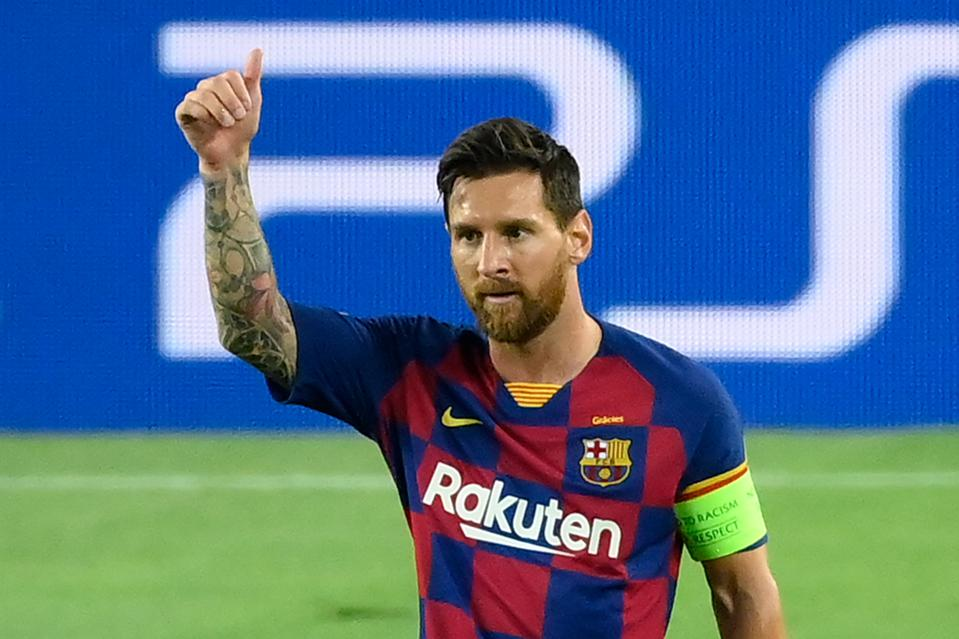

In [5]:
bucket_name = f"cdk-sagemaker-data-{acc_id}-{acc_region}"
model_bucket = f"cdk-sagemaker-models-{acc_id}-{acc_region}"

s3_bucket = session.resource("s3").Bucket(bucket_name)
s3_model_bucket = session.resource("s3").Bucket(model_bucket)

image_key = "lionel_messi.jpg"

model_key = "pytorch_yolo.tar.gz"

model_data_url = f"s3://{model_bucket}/{model_key}"


retrieved_image = s3_bucket.Object(image_key).get()
image_bytes = retrieved_image["Body"].read()

# display image first

display(Image(image_bytes))

local files

sagemaker

In [6]:
sagemaker_endpoints = sagemaker_client.list_endpoints()["Endpoints"]

endpoint = "PytorchPersonDetectionEndpoint"
for endpoint in sagemaker_endpoints:
    if isinstance(endpoint,str) and endpoint in endpoint["EndpointName"]:
        endpoint = endpoint["EndpointName"]

endpoint_arn = endpoint["EndpointArn"]
endpoint_name = endpoint["EndpointName"]
endpoint_name

'YOLOPersonDetection-ServerlessEndpoint'

In [ ]:
response = sagemaker_runtime.invoke_endpoint(
    EndpointName=endpoint_name, ContentType="image/jpeg", Body=image_bytes, Accept="application/x-npy"
)

response

ModelError: An error occurred (ModelError) when calling the InvokeEndpoint operation: Received server error (503) from model with message "{
  "code": 503,
  "type": "InternalServerException",
  "message": "Unsupported model output data type."
}
". See https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#logEventViewer:group=/aws/sagemaker/Endpoints/YOLOPersonDetection-ServerlessEndpoint in account 711387129682 for more information.

In [8]:
import io
from PIL import Image

# response['Body'].read() is a binary stream, so we need to decode it to get the image
image = Image.open(io.BytesIO(response["Body"].read()))

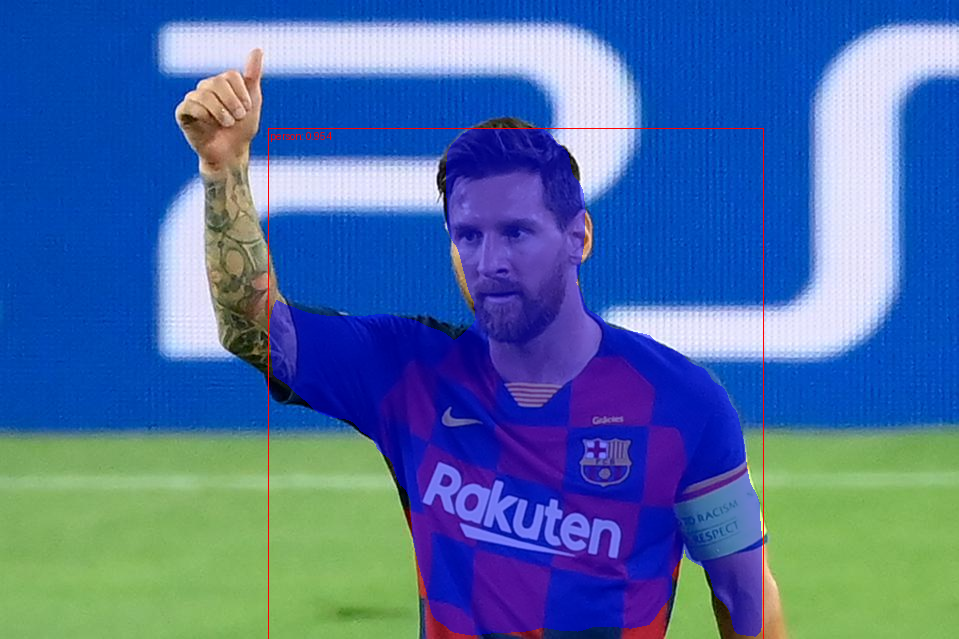

In [21]:
display(image)

In [ ]:
# locally deploy as a sagemaker endpoint

import sagemaker
from sagemaker.pytorch import PyTorchModel
import boto3
from os import environ
from pathlib import Path
sagemaker_session = sagemaker.LocalSession(
    session
)
sagemaker_session.config = {"local": {"local_code": True}}
DUMMY_IAM_ROLE = "arn:aws:iam::111111111111:role/service-role/AmazonSageMaker-ExecutionRole-20200101T000001"

role = DUMMY_IAM_ROLE

model_path = Path(
    "../models/pytorch_yolo/pytorch_yolo.tar.gz"
)

model = PyTorchModel(
    entry_point="inference.py",
    role=role,
    framework_version="2.6.0",
    py_version="py312",
    model_data=str(model_path),
)

predictor = model.deploy(
    initial_instance_count=1,
    instance_type="local",
    endpoint_name="sagemaker-endpoint",
)

[04/16/25 20:10:39] INFO     Found credentials in environment variables.                        ]8;id=366117;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=488926;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/credentials.py#1213\1213]8;;\

[04/16/25 20:10:41] INFO     Repacking model artifact (../models/pytorch_yolo/pytorch_yolo.tar.gz),    ]8;id=399811;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/model.py\model.py]8;;\:]8;id=108704;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/model.py#820\820]8;;\
                             script artifact (None), and dependencies ([]) into single tar.gz file                 
                             located at                                                                            
                             s3://sagemaker-us-east-1-711387129682/pytorch-inference-2025-04-17-01-10-             
                             40-257/model.tar.gz. This may take some time depending on model size...               

[04/16/25 20:10:55] INFO     Creating model with name: pytorch-inference-2025-04-17-01-10-55-983    ]8;id=655556;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=443045;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/session.py#4094\4094]8;;\

                    INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=921063;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=115127;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

[04/16/25 20:10:56] INFO     Creating endpoint-config with name sagemaker-endpoint                  ]8;id=565582;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=955478;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/session.py#6019\6019]8;;\

...

[04/16/25 20:10:57] INFO     Creating endpoint with name sagemaker-endpoint                         ]8;id=107809;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=30604;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/session.py#4841\4841]8;;\

                    INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=972540;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=321563;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

[04/16/25 20:10:58] INFO     'Docker Compose' found using Docker CLI.                                  ]8;id=756610;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/image.py\image.py]8;;\:]8;id=503808;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/image.py#168\168]8;;\

                    INFO     serving                                                                   ]8;id=558949;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/image.py\image.py]8;;\:]8;id=453107;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/image.py#338\338]8;;\

                    INFO     creating hosting dir in                                                   ]8;id=302619;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/image.py\image.py]8;;\:]8;id=174146;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/image.py#341\341]8;;\
                             /private/var/folders/yf/mvs3jvd13b3611j01cl4sn3c0000gq/T/tmpalbzf893                  

In [ ]:
from sagemaker.serializers import DataSerializer

ds = DataSerializer(content_type="application/x-image")

# predict on the endpoint
with open("lionel_messi.jpg", "rb") as file:
    img = file.read()
    ser = ds.serialize(img)


response = predictor.predict(
    img, {"ContentType": "application/x-image", "Accept": "application/x-image"}
)
response

hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,217 [INFO ] epollEventLoopGroup-3-3 TS_METRICS - ts_inference_requests_total.Count:1.0|#model_name:model,model_version:default|#hostname:8a66fce80440,timestamp:1744318517
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,223 [INFO ] W-9006-model_1.0 org.pytorch.serve.wlm.WorkerThread - Looping backend response at: 1744318517223
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,247 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - Backend received inference at: 1744318517
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,248 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - [INFO] input_fn-thread id: MainThread
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,248 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - [INFO] input_fn-process id: 71
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,248 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - [INFO] input_fn-content_type: application/x-image
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,292 [INFO ] W-9006-model_1.0 org.pytor

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:11                                                                                   │
│                                                                                                  │
│    8 │   ser = ds.serialize(img)                                                                 │
│    9                                                                                             │
│   10                                                                                             │
│ ❱ 11 response = predictor.predict(                                                               │
│   12 │   img, {"ContentType": "application/x-image", "Accept": "application/x-image"}            │
│   13 )                                                                                           │
│   14 response                                                                                    │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/base_predicto │
│ r.py:213 in predict                                                                              │
│                                                                                                  │
│   210 │   │   │   request_args["InferenceComponentName"] = inference_component_name              │
│   211 │   │                                                                                      │
│   212 │   │   response = self.sagemaker_session.sagemaker_runtime_client.invoke_endpoint(**req   │
│ ❱ 213 │   │   return self._handle_response(response)                                             │
│   214 │                                                                                          │
│   215 │   def _handle_response(self, response):                                                  │
│   216 │   │   """Placeholder docstring"""                                                        │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/base_predicto │
│ r.py:219 in _handle_response                                                                     │
│                                                                                                  │
│   216 │   │   """Placeholder docstring"""                                                        │
│   217 │   │   response_body = response["Body"]                                                   │
│   218 │   │   content_type = response.get("ContentType", "application/octet-stream")             │
│ ❱ 219 │   │   return self.deserializer.deserialize(response_body, content_type)                  │
│   220 │                                                                                          │
│   221 │   def _create_request_args(                                                              │
│   222 │   │   self,                                                                              │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/base_deserial │
│ izers.py:251 in deserialize                                                                      │
│                                                                                                  │
│   248 │   │   finally:                                                                           │
│   249 │   │   │   stream.close()                                                                 │
│   250 │   │                                                                                      │
│ ❱ 251 │   │   raise ValueError("%s cannot read content type